## CMPINF 2100 Week 12

### Measuring CLASSIFICATION PERFORMANCE - Confusion Matrix

## Import modules

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
import statsmodels.formula.api as smf

## Read Data

Read the data from LAST week

In [3]:
df = pd.read_csv('../week_11/week_11_intro_binary_classification.csv')

In [4]:
df.info

<bound method DataFrame.info of             x  y
0   -0.457429  1
1    0.425948  1
2   -0.784695  0
3   -1.925209  0
4    2.252617  1
..        ... ..
110 -0.791672  0
111  0.452238  1
112  0.535510  1
113 -0.532739  0
114  0.317661  0

[115 rows x 2 columns]>

## Fit the model

In [5]:
fit_glm = smf.logit(formula='y ~ x', data=df).fit()

Optimization terminated successfully.
         Current function value: 0.560099
         Iterations 6


## Predict the training set

In [6]:
df_copy = df.copy()

In [7]:
df_copy['pred_probability'] = fit_glm.predict( df )

In [8]:
df_copy.head()

,x,y,pred_probability
0,-0.457429,1,0.270709
1,0.425948,1,0.513678
2,-0.784695,0,0.201258
3,-1.925209,0,0.061306
4,2.252617,1,0.901780


## Classify the training set

In [9]:
df_copy['pred_class'] = np.where(df_copy.pred_probability > 0.5, 1, 0)

## Accuracy 

The Accuracy is the PROPORTION of CORRECT CLASSIFICATIONS!!!

In [10]:
np.mean( df_copy.y == df_copy.pred_class )

0.6782608695652174

But...Accuracy does not tell us HOW the model was right...ACCURACY does NOT tell us HOW the model was wrong!!

Many times we need MORE INFORMATION or DETAILS about **HOW** the classification were RIGHT or WRONG!!!

We need to examine the ERRORS!!!

The ERRORS in a BINARY CLASSIFICATION problem are typically organized in a graphical tool know as the **CONFUSION MATRIX**

## CONFUSION MATRIX

The CONFUSION MATRIX has a special and magical sounding name. But you already know how to calculate the CONFUSION MATRIX because the CONFUSION MATRIX is nothing more than the COUNTS for the **COMBINATION** of 2 categorical variable!!!

In [11]:
df_copy.y.value_counts()

y
0    67
1    48
Name: count, dtype: int64

In [12]:
df_copy.pred_class.value_counts()

pred_class
0    72
1    43
Name: count, dtype: int64

We learned about DODGED BAR CHART and HEAT MAPS for visualizing the combinations between the CATEGORICAL VARIABLES!!!

The CONFUSION MATRIX is a HEAT MAP between the OBSERVED OUPUT CLASS and the PREDICTED CLASS!!!

We need to first CROSS-TABULATE the observed output with the predicted class

In [14]:
pd.crosstab( df_copy.y, df_copy.pred_class)

pred_class,0,1
y,,
0,51,16
1,21,27


Let's visualize the CONFUSION MATRIX as a Seaborn heatmap!!!

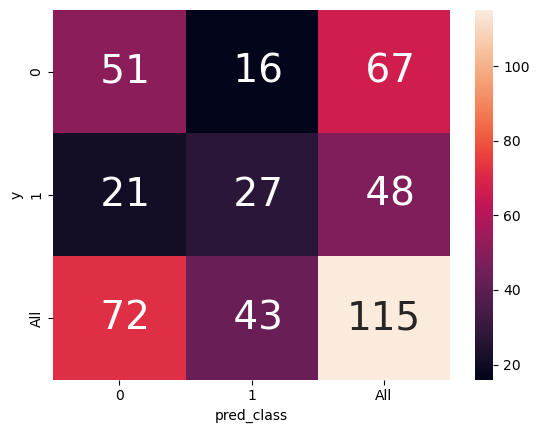

In [18]:
fig, ax = plt.subplots()

sns.heatmap( pd.crosstab(df_copy.y, df_copy.pred_class, margins=True),
            annot=True, annot_kws={'size':28}, fmt='3d')
plt.show()

In [19]:
df_copy.y.value_counts()

y
0    67
1    48
Name: count, dtype: int64

In [20]:
df_copy.pred_class.value_counts()

pred_class
0    72
1    43
Name: count, dtype: int64